In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.lines as mlines
import itertools
import random
import math

from collections import Counter

import tailestim
from tailestim import HillEstimator, KernelTypeEstimator, MomentsEstimator

from pprint import pprint

In [7]:

G1 = nx.Graph()

with open("mystery_edges1.txt", 'r') as f1:
    for line in f1.readlines():   
        i = line.split()[0]
        for j in line.split()[1:]:
            G1.add_edge(int(i), int(j))



G2 = nx.Graph()

with open("mystery_edges2.txt", 'r') as f2:
    for line in f2.readlines():   
        i = line.split()[0]
        for j in line.split()[1:]:
            G2.add_edge(int(i), int(j))

print(G1)
print(G2)


Graph with 200 nodes and 591 edges
Graph with 196 nodes and 574 edges


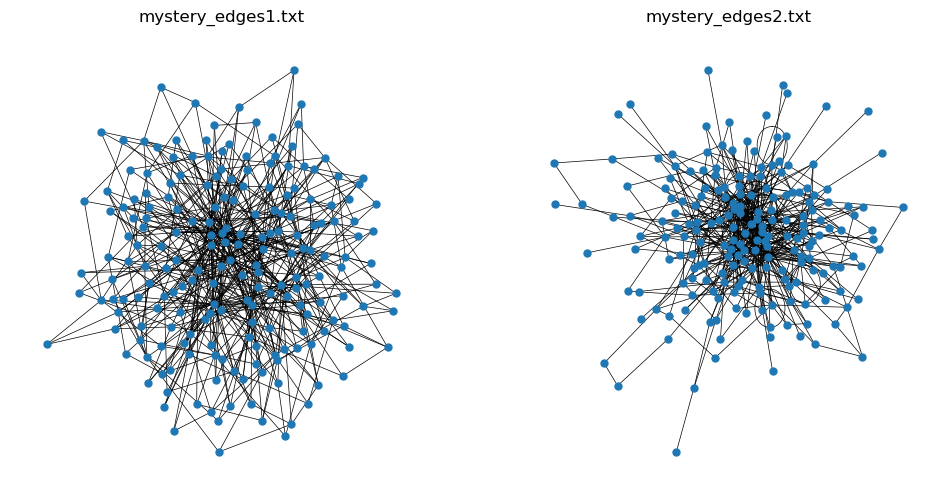

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

nx.draw(G1, node_size=25, width=0.5, ax=ax[0])
ax[0].set_title("mystery_edges1.txt")

nx.draw(G2, node_size=25, width=0.5, ax=ax[1])
ax[1].set_title("mystery_edges2.txt")

plt.show()

(a) Fit the growth model to each provided network to determine the most likely m value.

In [9]:
def get_gamma(G: nx.Graph) -> float:
    """
    Gets the estimated gamma for a BA graph
    
    """

    degree = list(dict(G1.degree()).values()) # Degree sequence

    # Initialize and fit the Hill estimator
    estimator = HillEstimator()
    estimator.fit(degree)

    # # # Get estimated values
    result = estimator.get_result()
    gamma = result.gamma_

    return gamma

gamma1_est = np.mean([get_gamma(G1) for _ in range(10)])
gamma2_est = np.mean([get_gamma(G2) for _ in range(10)])

print(gamma1_est)
print(gamma2_est)




2.7244409459190964
2.7244409459190964


(b) Generate an ensemble of one hundred networks with the fit model. These ensembles should have approximately the same number of nodes and edges as the provided network.

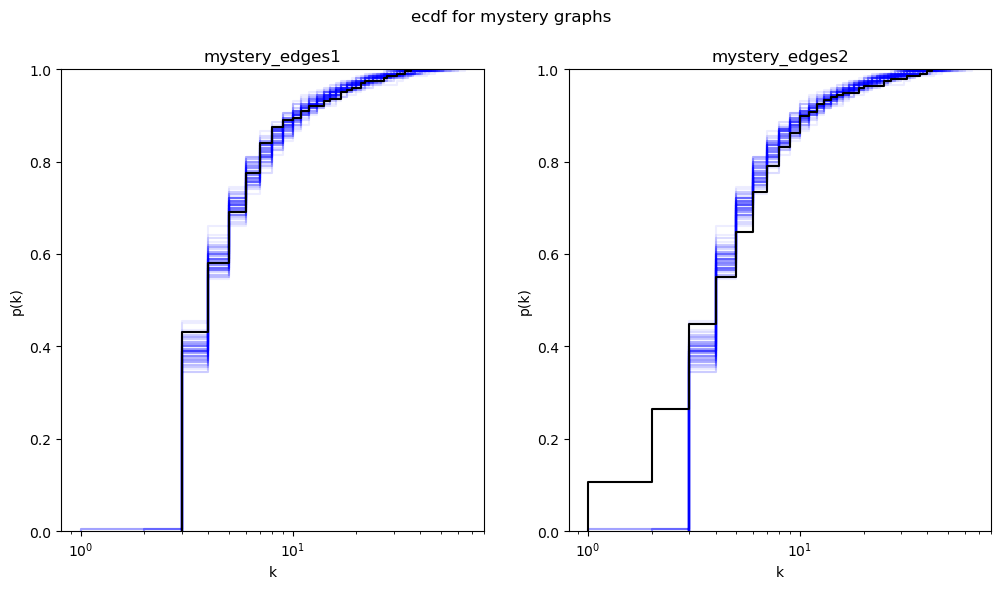

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))


for _ in range(100):
    G = nx.barabasi_albert_graph(200, 3)
    ax[0].ecdf([d[1] for d in list(G.degree())], color="blue", alpha=0.07)
    ax[1].ecdf([d[1] for d in list(G.degree())], color="blue", alpha=0.07)


ax[0].ecdf([d[1] for d in list(G1.degree())], color="black")
ax[0].set_xscale('log')
ax[0].set_title("mystery_edges1")
ax[0].set_xlabel("k")
ax[0].set_ylabel("p(k)")


ax[1].ecdf([d[1] for d in list(G2.degree())], color="black")
ax[1].set_xscale('log')
ax[1].set_title("mystery_edges2")
ax[1].set_xlabel("k")
ax[1].set_ylabel("p(k)")


plt.suptitle("ecdf for mystery graphs")

plt.show()


(c) Choose three graph-level attributes. Plot a distribution (kernel-density estimates and cumulative distribution functions are good choices here) of each graph-level attribute for each graph ensemble. Add a reference line for the mystery network so we can compare its attributes to the ensemble

Recall in class 04, we looked at modularity in random (i.e., G(n, m)) graphs. Expand
this result by replicating Figure 2 from Guimera, R., Sales-Pardo, M., & Amaral,
L.A.N. (2004). Modularity from fluctuations in random graphs and complex networks.
Physical Review E, 70(2), 025101. Comment on this result, especially as it relates to
modularity as a measure of partition quality.

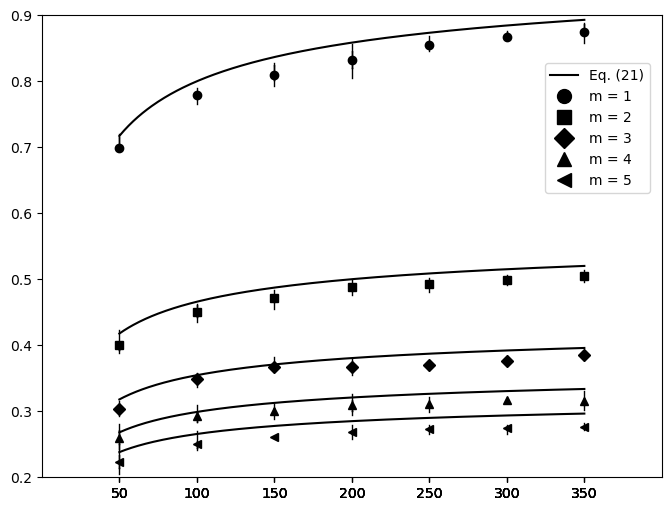

In [ ]:
S = 50
m = 2
a = 0.165

def M_SF(S, m, a):
    return (a + ((1 - a) / m)) * (1 - (2 / math.sqrt(S)))

def best_louvain_modularity(G, iters):

    best = -1.0
    
    for _ in range(iters):
        communities = nx.community.louvain_communities(G)
        modularity = nx.community.modularity(G, communities)

        if modularity > best:
            best = modularity

    return best


fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ms = range(1, 6)
ns = range(50, 351, 50)


# plot prediction function
for m in ms:
        
    xs = np.arange(50, 351)
    
    pred_ys = [M_SF(S, m, a) for S in np.arange(50, 351)]
    
    ax.plot(xs, pred_ys, color="black")

markers = "osD^<"

# plot actual values
for m, marker in zip(ms, markers):

    modularities = []

    for n in ns:

        # get best louvain modularity for 10 BA graphs
        mods = []
        for _ in range(10):
            G = nx.barabasi_albert_graph(n, m)
            mods.append(best_louvain_modularity(G, iters=1))
            
        modularities.append(mods)
        
        ax.plot(n, np.mean(mods), marker=marker, color="black")
                
        
    ax.boxplot(modularities, positions=ns, widths=0.0, showfliers=False)


# make legend
handles = []
handles.append(mlines.Line2D([], [], color='black', linestyle='-', markersize=10, label=f'Eq. (21)'))
for i, marker in enumerate(markers):
    handles.append(mlines.Line2D([], [], color='black', marker=marker, linestyle='None', markersize=10, label=f'm = {ms[i]}'))

plt.legend(handles=handles, loc="best", bbox_to_anchor=(0.8, 0.6))

ax.set_xbound(0, 400)
ax.set_ybound(0.2, 0.9)
plt.show()

(a) Download a network dataset from https://networkrepository.com/ with between 1,000 < N < 5,000 nodes. Select a modularity maximization algorithm to detect communities in this graph.
    
    i. Visualize your network, coloring the nodes by community membership.
    ii. Report the modularity of the partition your algorithm found.
    iii. Report the number of communities detected.
    iv. Store your partition as a dictionary, in the form of {node id: community id}.


(b) Using the same network as in (a), use graph-tool to create a partition of your network (i.e., run community detection). Visualize your network again, coloring the nodes by community membership; use the same network visualization layout as the in (a). Store your partition as a dictionary.


(c) Create a degree-preserving randomization of your network, and run the two community detection algorithms from above on your randomized graph. Store each
partition as a dictionary.


(d) You should now have four different dictionaries, corresponding to the partitions created in (a-c). Create a figure with four subplots: In each, plot the community size distribution of each partition. Your figure should be publication-ready quality, with well-labeled, consistent axes, log-scaled where relevant, etc.

In [ ]:
# read edgelist
dnc = pd.read_csv("email-dnc.edges", header=None, names=["node_i", "node_j", "timestamp"]).astype(int)

# make directed graph
G_dnc = nx.from_pandas_edgelist(dnc, "node_i", "node_j", create_using=nx.DiGraph)


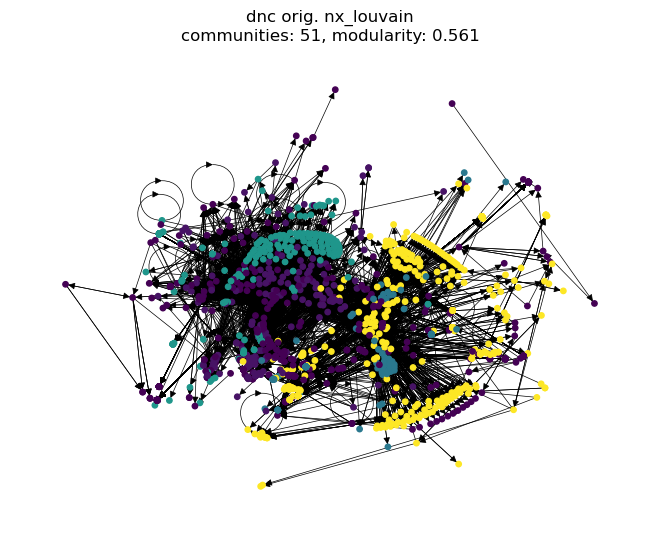

In [102]:
# get communities
nx_louvain_communities = nx.community.louvain_communities(G_dnc, seed=867)

# create community dictionary
louvain_communities_dict = {}

for i, community in enumerate(nx_louvain_communities):
    for node in community:
        louvain_communities_dict[node] = i


# get community sizes for colormap
max_community = max([len(c) for c in nx_louvain_communities])
min_community = min([len(c) for c in nx_louvain_communities])

proportional_sizes = [((len(c) / max_community) * 2) - 1 for c in nx_louvain_communities]


# set colors
colors = []
for node in G_dnc:
    for i, community in enumerate(nx_louvain_communities):
        if node in community:
            rgba = mpl.colormaps["viridis"](proportional_sizes[i])
            colors.append(rgba)
            break


# set positions and draw
pos = nx.kamada_kawai_layout(G_dnc)

nx.draw(G_dnc, pos=pos, node_size=15, node_color=colors, width=0.5)

modularity = nx.community.modularity(G_dnc, nx_louvain_communities)
num_communities = len(nx_louvain_communities)

plt.title(f"dnc orig. nx_louvain\ncommunities: {num_communities}, modularity: {round(modularity, 3)}")
plt.show()


# Degree preserving model for DNC email network

In [ ]:
in_deg_seq = [d[1] for d in G_dnc.in_degree()]
out_deg_seq = [d[1] for d in G_dnc.out_degree()]

G_dnc_rand = nx.directed_configuration_model(in_deg_seq, out_deg_seq, seed=867)


nx_louvain_communities_rand = nx.community.louvain_communities(G_dnc_rand, seed=867)

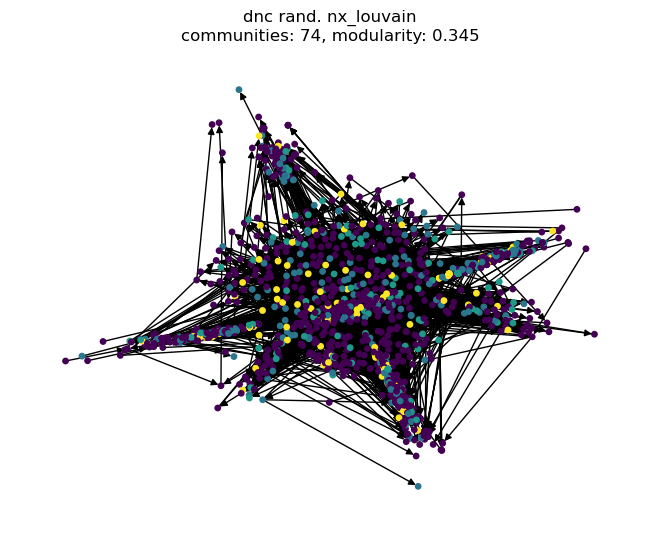

In [103]:
# create community dictionary
louvain_communities_rand_dict = {}

for i, community in enumerate(nx_louvain_communities_rand):
    for node in community:
        louvain_communities_rand_dict[node] = i


# get community sizes for colormap
max_community = max([len(c) for c in nx_louvain_communities_rand])
min_community = min([len(c) for c in nx_louvain_communities_rand])

proportional_sizes = [((len(c) / max_community) * 2) - 1 for c in nx_louvain_communities_rand]


# set colors
colors = []
for node in G_dnc_rand:
    for i, community in enumerate(nx_louvain_communities_rand):
        if node in community:
            rgba = mpl.colormaps["viridis"](proportional_sizes[i])
            # hex = mpl.colors.rgb2hex(rgba)
            colors.append(rgba)
            break


# set positions and draw
pos = nx.kamada_kawai_layout(G_dnc_rand)

nx.draw(G_dnc_rand, pos=pos, node_size=15, node_color=colors)

modularity = nx.community.modularity(G_dnc_rand, nx_louvain_communities_rand)
num_communities = len(nx_louvain_communities_rand)

plt.title(f"dnc rand. nx_louvain\ncommunities: {num_communities}, modularity: {round(modularity, 3)}")
plt.show()


Community detection and the consensus partition (25 points).

Many community detection algorithms are stochastic: their output can change across runs due to random seeds, initialization, or tie-breaking. In this problem, you will implement a basic consensus community detection pipeline and compare it to both a single stochastic run and a deterministic baseline.

- (a)  Do a brief literature search for consensus clustering in networks (or consensus community detection) in networks. Define the idea in your own words, define what a consensus matrix is, cite at least one peer-reviewed source.
    
- (b) Generate a network from an undirected microcanonical stochastic block model (a “planted-partition” model) graph with four assortative communities of size 100, 200, 300, 400 ($N = 1, 000$). Report the within-block and between-block connection probabilities that you used, and store the planted community labels as a dictionary \texttt{\{node id : planted block\}}.

- (c) Choose a stochastic algorithm of your choice (e.g., Louvain/Leiden, label propagation, etc.; there are many). Run this algorithm R = 100 times on your graph, using different random seeds. For each run r, store the partition as a dictionary \texttt{\{node id : community id\}} and record the modularity and the number of detected communities. Create a figure with two subplots that visualize the 1) distribution of modularity values of your partitions, and 2) the distribution of number of communities across runs.

- (d) Let $b^{(r)}(i)$ be the community label of node $i$ in run $r$. Implement the consensus matrix $C$ defined by

    <!-- \begin{equation*} -->
$C_{ij} = \frac{1}{R} \sum_{r=1}^{R} \mathbb{1} \{ b^{(r)}(i) = b^{(r)}(j) \}$
    <!-- \end{equation*} -->

Create a visualization of $C$ (using \texttt{plt.imshow()} or \texttt{plt.matshow()}). 
    
- (e) Convert $C$ into a consensus graph (weighted), with the nodes of $C$ being the same nodes as your original graph, and give edge $(i, j)$ weight $C_{ij}$ . Because $C$ will likely be typically dense, apply a filtering rule: choose a threshold $\tau$ and discard edges with $C_{ij} < \tau$ . State and justify your choice of $\tau$ . Finally (!), run a community detection algorithm on the thresholded consensus graph to get a final partition $b^{(cons)}$. (You may use the same stochastic algorithm with a fixed seed, or a deterministic weighted-community method.)
    
- (f) Repeat steps (b)-(e), with less strong-community structure. This means the within-block probabilities (i.e., your $p_{aa}$, $p_{bb}$, $p_{cc}$, etc.) should be smaller this time, and/or your between-block probabilities should be larger.
    
- (g) Across your experiments, does the consensus partition help improve the community detection process? Under what conditions did it help, if any? Discuss.

[[0.45 0.2  0.2  0.25]
 [0.2  0.45 0.25 0.25]
 [0.2  0.25 0.45 0.3 ]
 [0.25 0.25 0.3  0.45]]
[[0.45  0.25  0.25  0.25 ]
 [0.25  0.425 0.3   0.3  ]
 [0.25  0.3   0.415 0.35 ]
 [0.25  0.3   0.35  0.415]]


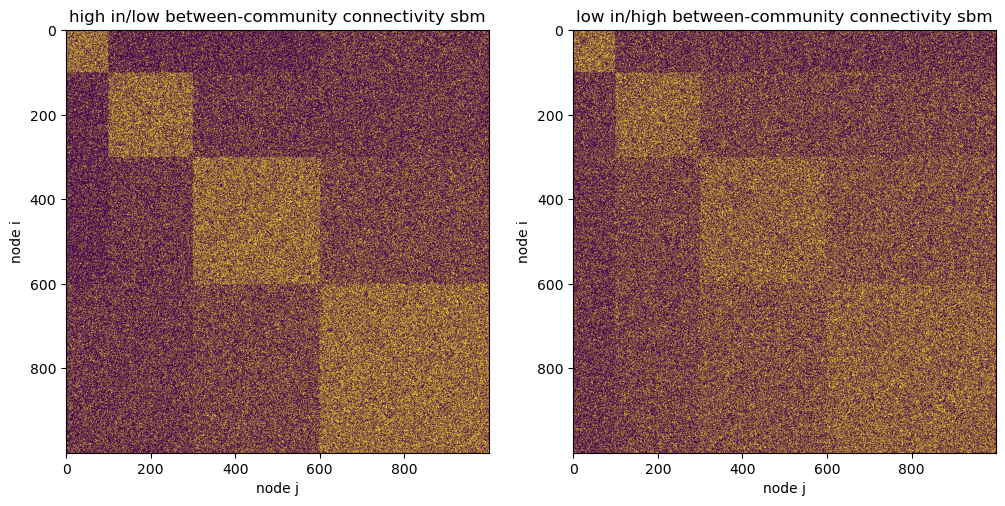

In [227]:
def p_high():
    # in community
    p00 = 0.45
    p11 = 0.45
    p22 = 0.45
    p33 = 0.45

    # between community
    p01 = 0.2
    p02 = 0.2
    p03 = 0.25
    p12 = 0.25
    p13 = 0.25
    p23 = 0.30

    p = [
        [p00, p01, p02, p03],
        [0.0, p11, p12, p13],
        [0.0, 0.0, p22, p23],
        [0.0, 0.0, 0.0, p33]
    ]

    p += np.triu(p, k=1).T  # make symmetric

    return p

def p_low():
    # in community
    p00 = 0.45
    p11 = 0.425
    p22 = 0.415
    p33 = 0.415

    # between community
    p01 = 0.25
    p02 = 0.25
    p03 = 0.25
    p12 = 0.30
    p13 = 0.30
    p23 = 0.35

    p = [
        [p00, p01, p02, p03],
        [0.0, p11, p12, p13],
        [0.0, 0.0, p22, p23],
        [0.0, 0.0, 0.0, p33]
    ]

    p += np.triu(p, k=1).T  # make symmetric

    return p

print(p_high())
print(p_low())

sizes = [100, 200, 300, 400]

G_sbm_high = nx.stochastic_block_model(sizes=sizes, p=p_high())
G_sbm_low = nx.stochastic_block_model(sizes=sizes, p=p_low())

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(nx.to_numpy_array(G_sbm_high))
ax[0].set_title("high in/low between-community connectivity sbm")
ax[0].set_xlabel("node j")
ax[0].set_ylabel("node i")
ax[1].imshow(nx.to_numpy_array(G_sbm_low))
ax[1].set_title("low in/high between-community connectivity sbm")
ax[1].set_xlabel("node j")
ax[1].set_ylabel("node i")

# plt.show()
plt.savefig("figures/sbm_matrix.png")


In [228]:
iters = 100

modularities_high = []
modularities_low = []
num_communities_high = []
num_communities_low = []
community_dicts_high = []
community_dicts_low = []


for _ in range(iters):

    # get our communities and modularities
    communities_high = nx.community.louvain_communities(G_sbm_high)
    communities_low = nx.community.louvain_communities(G_sbm_low)

    modularity_high = nx.community.modularity(G_sbm_high, communities_high)
    modularities_high.append(modularity_high)

    modularity_low = nx.community.modularity(G_sbm_low, communities_low)
    modularities_low.append(modularity_low)

    num_communities_high.append(len(communities_high))
    num_communities_low.append(len(communities_low))

    # label nodes by community
    community_dict_high = {}
    for i, community in enumerate(communities_high):
        for node in community:
            community_dict_high[node] = i

    community_dicts_high.append(community_dict_high)

    # label nodes by community
    community_dict_low = {}
    for i, community in enumerate(communities_low):
        for node in community:
            community_dict_low[node] = i

    community_dicts_low.append(community_dict_low)



# print(num_communities_high)
# print(modularities_high)
# print()
# print(num_communities_low)
# print(modularities_low)

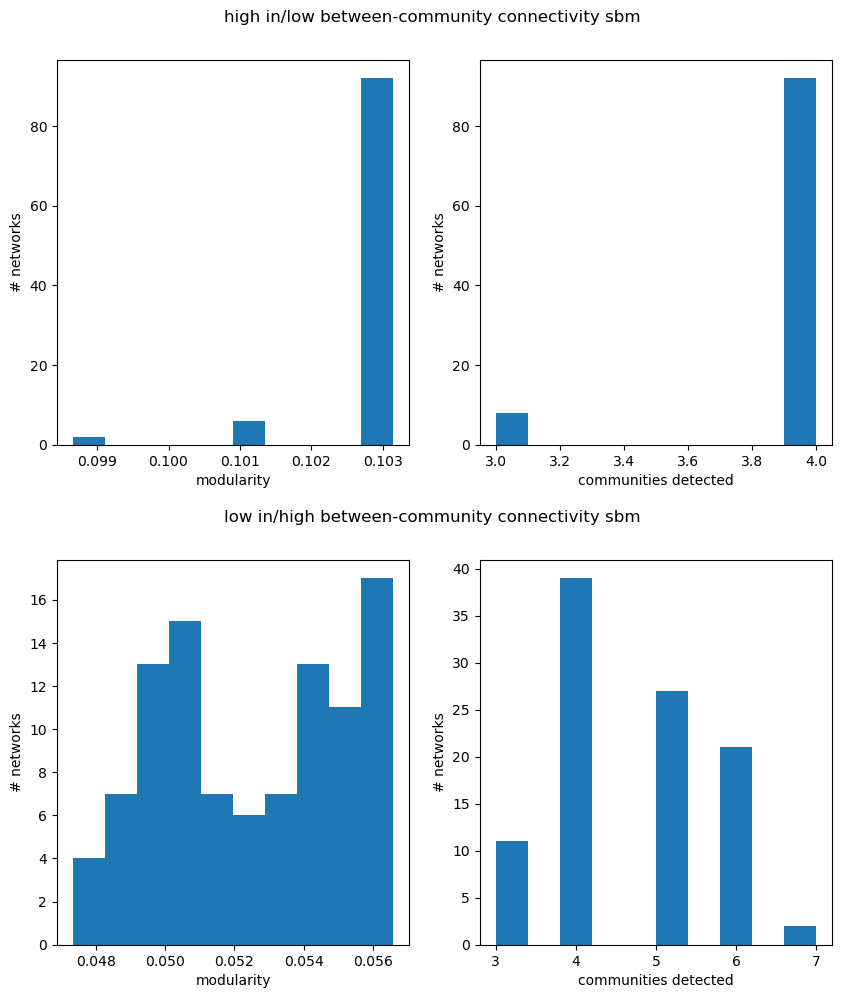

In [229]:
fig = plt.figure(figsize=(10, 10))

(row0, row1) = fig.subfigures(2, 1)

row0.suptitle("high in/low between-community connectivity sbm")
ax0 = row0.subplots(1, 2)

ax0[0].hist(modularities_high)
ax0[0].set_xlabel("modularity")
ax0[0].set_ylabel("# networks")

ax0[1].hist(num_communities_high)
ax0[1].set_xlabel("communities detected")
ax0[1].set_ylabel("# networks")


row1.suptitle("low in/high between-community connectivity sbm")
ax1 = row1.subplots(1, 2)

ax1[0].hist(modularities_low)
ax1[0].set_xlabel("modularity")
ax1[0].set_ylabel("# networks")

ax1[1].hist(num_communities_low)
ax1[1].set_xlabel("communities detected")
ax1[1].set_ylabel("# networks")

# plt.tight_layout()
# plt.show()
plt.savefig("figures/sbm_modularity_communities.png")

In [184]:
# fig, ax = plt.subplots(2, 2, figsize=(14, 12))

# ax[0, 0].hist(modularities_high)
# ax[0, 0].set_xlabel("modularity")
# ax[0, 0].set_ylabel("# networks")

# ax[0, 1].hist(num_communities_high)
# ax[0, 1].set_xlabel("communities detected")
# ax[0, 1].set_ylabel("# networks")
# # ax[1].set_xticks([3, 4])
# # ax[1].set_xbound(2.5, 4.5)

# ax[1, 0].hist(modularities_low)
# ax[1, 0].set_xlabel("modularity")
# ax[1, 0].set_ylabel("# networks")

# ax[1, 1].hist(num_communities_low)
# ax[1, 1].set_xlabel("communities detected")
# ax[1, 1].set_ylabel("# networks")

# plt.show()

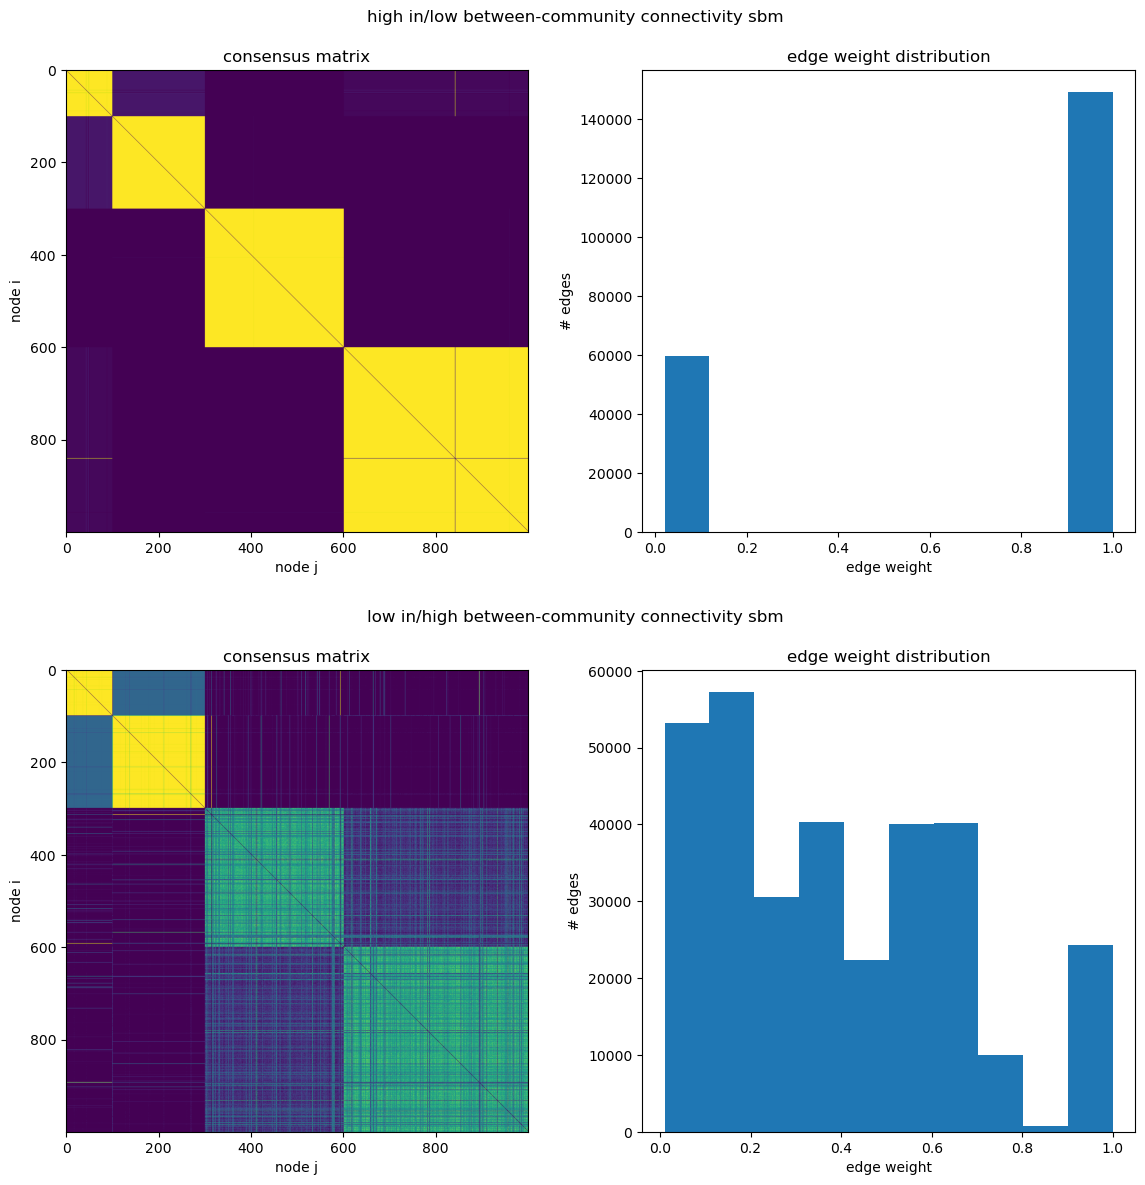

In [244]:
consensus_matrix_high = np.zeros((len(G_sbm_high), len(G_sbm_high)))
consensus_matrix_low = np.zeros((len(G_sbm_low), len(G_sbm_low)))

for community_dict in community_dicts_high:
    for i, j in itertools.combinations(community_dict.keys(), 2):
        if community_dict[i] == community_dict[j]:
            consensus_matrix_high[i, j] += 1


for community_dict in community_dicts_low:
    for i, j in itertools.combinations(community_dict.keys(), 2):
        if community_dict[i] == community_dict[j]:
            consensus_matrix_low[i, j] += 1


consensus_matrix_high /= iters
consensus_matrix_high += consensus_matrix_high.T

consensus_matrix_low /= iters
consensus_matrix_low += consensus_matrix_low.T


dist_high = [x for x in list(itertools.chain.from_iterable(np.triu(consensus_matrix_high, k=1))) if x != 0]
dist_low = [x for x in list(itertools.chain.from_iterable(np.triu(consensus_matrix_low, k=1))) if x != 0]


fig = plt.figure(figsize=(14, 12))

(row0, row1) = fig.subfigures(2, 1)

row0.suptitle("high in/low between-community connectivity sbm")

ax0 = row0.subplots(1, 2)
ax0[0].imshow(consensus_matrix_high)
ax0[0].set_title("consensus matrix")
ax0[0].set_xlabel("node j")
ax0[0].set_ylabel("node i")

ax0[1].hist(dist_high)
ax0[1].set_title("edge weight distribution")
ax0[1].set_xlabel("edge weight")
ax0[1].set_ylabel("# edges")

row1.suptitle("low in/high between-community connectivity sbm")

ax1 = row1.subplots(1, 2)
ax1[0].imshow(consensus_matrix_low)
ax1[0].set_title("consensus matrix")
ax1[0].set_xlabel("node j")
ax1[0].set_ylabel("node i")

ax1[1].hist(dist_low)
ax1[1].set_title("edge weight distribution")
ax1[1].set_xlabel("edge weight")
ax1[1].set_ylabel("# edges")


# plt.show()
# plt.tight_layout()
plt.savefig("figures/sbm_consensus.png")

4
[[0.9950495  0.00332226 0.00249377 0.002     ]
 [0.00331126 1.         0.00199601 0.00166667]
 [0.00248756 0.00199601 1.         0.00142857]
 [0.0059761  0.00166389 0.00142653 0.99875   ]]
[[0.98529412 0.00328947 0.00244499 0.00205339]
 [0.00328947 0.99257426 0.00196464 0.00170358]
 [0.00742574 0.01388889 0.92775041 0.04221252]
 [0.00992063 0.00165563 0.07475317 0.94663278]]


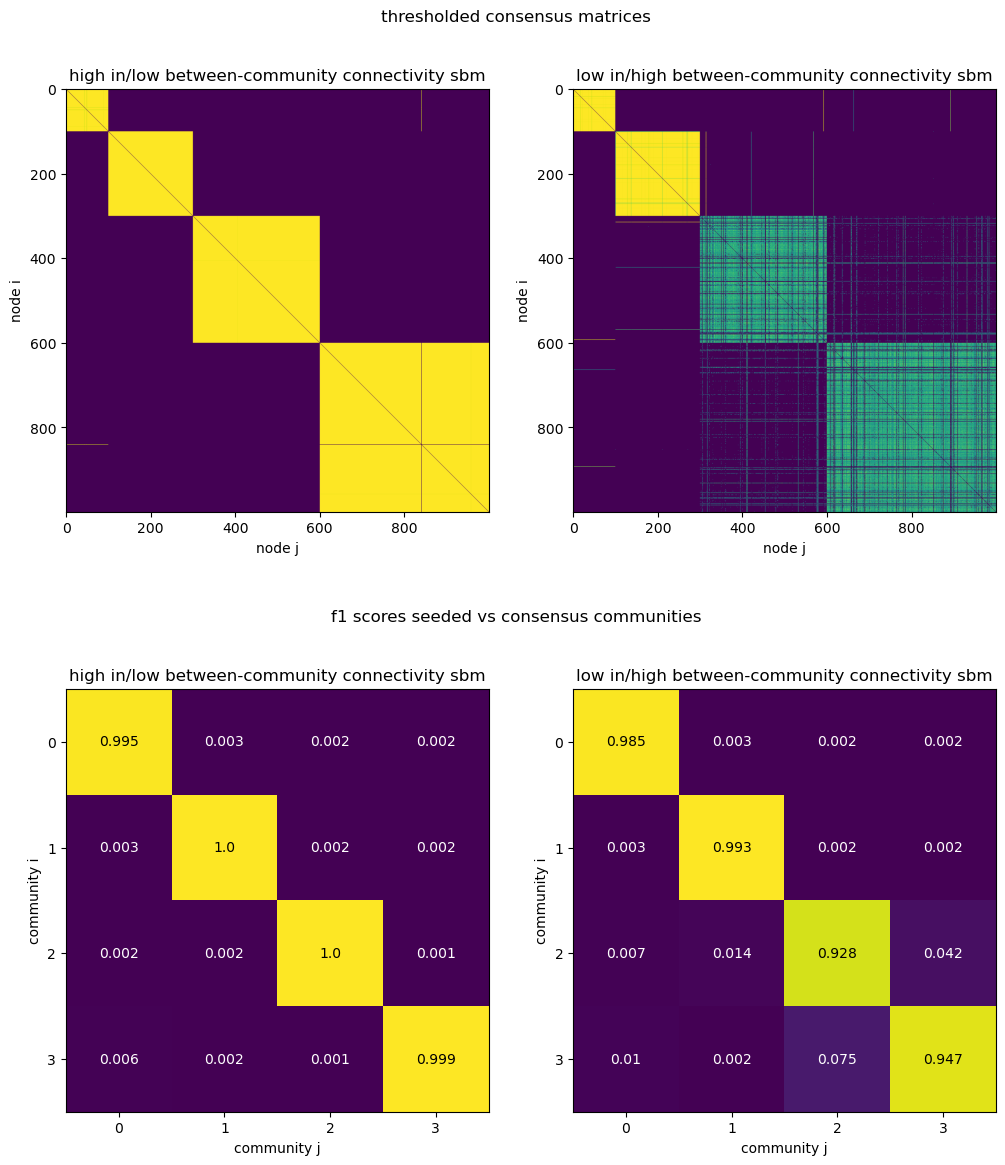

In [304]:
threshold_high = 0.25

threshold_matrix_high = consensus_matrix_high.copy()
threshold_matrix_high[threshold_matrix_high < threshold_high] = 0

threshold_low = 0.4

threshold_matrix_low = consensus_matrix_low.copy()
threshold_matrix_low[threshold_matrix_low < threshold_low] = 0


seeded_communities = [set(range(0, 100)), set(range(100, 300)), set(range(300, 600)), set(range(600, 1000))]


G_sbm_high_consensus = G_sbm_high.copy()

for i, j in G_sbm_high.edges:
    G_sbm_high_consensus.edges[i, j]["weight"] = threshold_matrix_high[i, j]

threshold_communities_high = sorted(nx.community.louvain_communities(G_sbm_high_consensus, weight="weight"), key=len)



match_high = np.zeros((4, 4))
for i, j in itertools.product(range(0, 4), range(0, 4)):
    # print(i, j)
    # match_high[i, j] = len(seeded_communities[i] - threshold_communities_high[j]) / len(seeded_communities[i])
    # print(len(seeded_communities[i] - threshold_communities_high[i]) / len(seeded_communities[i]))

    tp = len(seeded_communities[i] & threshold_communities_high[j])
    fp = len(threshold_communities_high[j] - seeded_communities[i])
    fn = len(seeded_communities[i] - threshold_communities_high[j])
    
    match_high[i, j] = (1 + (2 * tp)) / (1 + (2 * tp + fp + fn))

G_sbm_low_consensus = G_sbm_low.copy()

for i, j in G_sbm_low.edges:
    G_sbm_low_consensus.edges[i, j]["weight"] = threshold_matrix_low[i, j]

threshold_communities_low = sorted(nx.community.louvain_communities(G_sbm_low_consensus, weight="weight"), key=len)

print(len(threshold_communities_low))
match_low = np.zeros((4, 4))
for i, j in itertools.product(range(0, 4), range(0, 4)):

    tp = len(seeded_communities[i] & threshold_communities_low[j])
    fp = len(threshold_communities_low[j] - seeded_communities[i])
    fn = len(seeded_communities[i] - threshold_communities_low[j])
    
    match_low[i, j] = (1 + (2 * tp)) / (1 + (2 * tp + fp + fn))
    




fig = plt.figure(figsize=(12, 12))
(row0, row1) = fig.subfigures(2, 1)

row0.suptitle("thresholded consensus matrices")

ax0 = row0.subplots(1, 2)

ax0[0].imshow(threshold_matrix_high)
ax0[0].set_title("high in/low between-community connectivity sbm")
ax0[0].set_xlabel("node j")
ax0[0].set_ylabel("node i")

ax0[1].imshow(threshold_matrix_low)
ax0[1].set_title("low in/high between-community connectivity sbm")
ax0[1].set_xlabel("node j")
ax0[1].set_ylabel("node i")


row1.suptitle("f1 scores seeded vs consensus communities")

ax1 = row1.subplots(1, 2)

ax1[0].imshow(match_high)

for i, j in itertools.product(range(0, 4), range(0, 4)):
    if match_high[i, j] > 0.5:
        color = "k"
    else:
        color = "w"
    text = ax1[0].text(j, i, round(match_high[i, j], 3), ha="center", va="center", color=color)

ax1[0].set_title("high in/low between-community connectivity sbm")
ax1[0].set_xticks(range(0, 4))
ax1[0].set_yticks(range(0, 4))
ax1[0].set_xlabel("community j")
ax1[0].set_ylabel("community i")

ax1[1].imshow(match_low)

for i, j in itertools.product(range(0, 4), range(0, 4)):
    if match_low[i, j] > 0.5:
        color = "k"
    else:
        color = "w"
    text = ax1[1].text(j, i, round(match_low[i, j], 3), ha="center", va="center", color=color)

ax1[1].set_title("low in/high between-community connectivity sbm")
ax1[1].set_xticks(range(0, 4))
ax1[1].set_yticks(range(0, 4))
ax1[1].set_xlabel("community j")
ax1[1].set_ylabel("community i")



# plt.tight_layout()
# plt.show()
plt.savefig("figures/thresholded_consensus_matrices.png")

print(match_high)
print(match_low)

In [255]:
for i in itertools.product(range(0, 3)):
    print(i)


(0,)
(1,)
(2,)
